# Information Theory

Every time you check the weather app, you learn something. But how *much*
you learn depends on what you already expected. If it rains every day in
monsoon season, "rain tomorrow" carries almost no information. "Snow
tomorrow" carries a lot.

Claude Shannon turned that intuition into mathematics in the 1940s, giving
us a precise way to measure the information content of any source. This
chapter traces that idea from classical bits to quantum qubits, through
data compression and error correction.

The path: classical Shannon entropy (Section 10.1), its quantum
generalization via von Neumann entropy (10.2), data compression in both
domains (10.3), and error-correcting codes (10.4).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log2, sqrt
from itertools import product as iter_product
import heapq
from collections import Counter

## 10.1 Classical Information and Shannon Entropy

Alice sends messages to Bob using a four-letter alphabet: A, B, C, D.
Each letter encodes a mood.

| Symbol | Meaning |
|--------|-----------------|
| A | "I feel sad" |
| B | "I feel angry" |
| C | "I feel happy" |
| D | "I feel bored" |

Bob tracks the frequency of each letter over many messages and estimates
a **probability distribution** (pdf) for the source. Three scenarios
stand out.

### Constant, Uniform, and General Distributions

**Constant:** Alice always sends C. Bob knows what the next letter will be
before it arrives. No surprise, no information.

$$p(A)=0,\; p(B)=0,\; p(C)=1,\; p(D)=0.$$

**Uniform:** Each letter is equally likely. Maximum surprise, maximum
information.

$$p(A)=\tfrac{1}{4},\; p(B)=\tfrac{1}{4},\; p(C)=\tfrac{1}{4},\; p(D)=\tfrac{1}{4}.$$

**General:** Something in between.

$$P(A)=\tfrac{1}{2},\; P(B)=\tfrac{1}{4},\; P(C)=\tfrac{1}{8},\; P(D)=\tfrac{1}{8}.$$

The connection between uncertainty and information is deep. The more
uncertain the outcome, the more Bob learns by observing it. What he can
predict beforehand does not count: only novelty brings forth information.
The uniform distribution represents maximum uncertainty, and therefore
maximum information content.

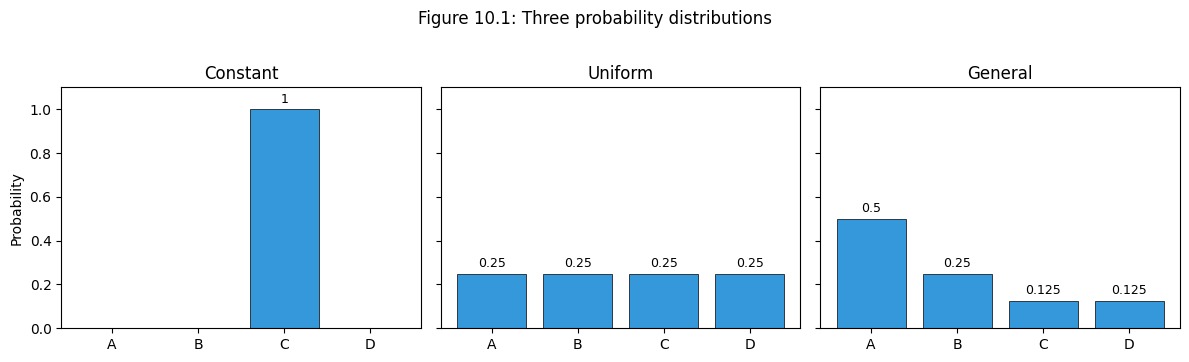

In [2]:
# Visualize the three distributions
labels = ['A', 'B', 'C', 'D']
dists = {
    'Constant': [0, 0, 1, 0],
    'Uniform': [0.25, 0.25, 0.25, 0.25],
    'General': [0.5, 0.25, 0.125, 0.125]
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (name, probs) in zip(axes, dists.items()):
    ax.bar(labels, probs, color='#3498db', edgecolor='black', linewidth=0.5)
    ax.set_title(name)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability' if ax == axes[0] else '')
    for i, p in enumerate(probs):
        if p > 0:
            ax.text(i, p + 0.03, f'{p}', ha='center', fontsize=9)
plt.suptitle('Figure 10.1: Three probability distributions', y=1.02)
plt.tight_layout()
plt.show()

### Shannon Entropy

Shannon, building on classical statistical thermodynamics, introduced a
precise measure of uncertainty.

**Definition 10.1.1.** The **Shannon entropy** of a source with probability
distribution $\{p_i\}$ is

$$H_S = -\sum_{i=1}^{n} p_i \log_2(p_i) = \sum_{i=1}^{n} p_i \log_2\!\left(\frac{1}{p_i}\right),$$

with the convention $0 \times \log_2(0) = 0$.

The minus sign ensures entropy is always positive or zero (since $\log_2(p_i) \le 0$
for $0 < p_i \le 1$).

**Constant pdf:**

$$H_S = -0\log_2(0) - 0\log_2(0) - 1\log_2(1) - 0\log_2(0) = 0.$$

Zero entropy means zero uncertainty.

**Uniform pdf:**

$$H_S = -4 \times \tfrac{1}{4}\log_2(\tfrac{1}{4}) = -\log_2(\tfrac{1}{4}) = 2.$$

Bob needs 2 bits to describe which letter arrived. That checks out.

**General pdf:**

$$H_S = -\tfrac{1}{2}\log_2(\tfrac{1}{2}) - \tfrac{1}{4}\log_2(\tfrac{1}{4}) - \tfrac{1}{8}\log_2(\tfrac{1}{8}) - \tfrac{1}{8}\log_2(\tfrac{1}{8}) = 1.75.$$

In between, as expected. Two complementary slogans:

> **Greater entropy means greater uncertainty.**
>
> **Greater entropy means more information.**

In [3]:
def shannon_entropy(probs):
    """Compute Shannon entropy H_S = -sum(p * log2(p)) for a probability distribution."""
    H = 0.0
    for p in probs:
        if p > 0:
            H -= p * log2(p)
    return H

# Verify the three examples
for name, probs in dists.items():
    H = shannon_entropy(probs)
    print(f'{name:10s}  H = {H:.4f}')

Constant    H = 0.0000
Uniform     H = 2.0000
General     H = 1.7500


### Binary Entropy: H vs p

The simplest source emits 0 with probability $p$ and 1 with probability
$1-p$. The entropy $H(p) = -p\log_2(p) - (1-p)\log_2(1-p)$ peaks at
$p = 0.5$ (maximum uncertainty) and drops to zero at the extremes (certainty).

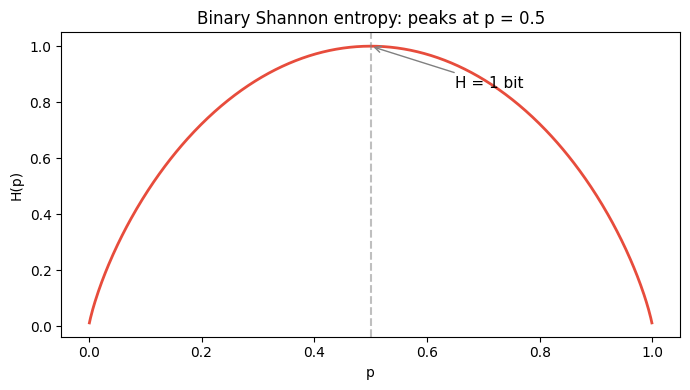

In [4]:
p = np.linspace(0.001, 0.999, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, H, color='#e74c3c', linewidth=2)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('p')
ax.set_ylabel('H(p)')
ax.set_title('Binary Shannon entropy: peaks at p = 0.5')
ax.annotate('H = 1 bit', xy=(0.5, 1.0), xytext=(0.65, 0.85),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11)
plt.tight_layout()
plt.show()

### Programming Drill 10.1.1

*Write a simple program that lets the user choose how many letters the
source alphabet has, enter the probability distribution, visualize it,
and compute its Shannon entropy.*

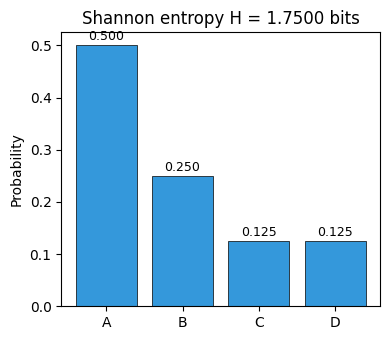

Shannon entropy: 1.7500 bits


In [5]:
def entropy_calculator(probs, labels=None):
    """Compute and visualize Shannon entropy for a given distribution."""
    probs = np.array(probs, dtype=float)
    assert np.isclose(probs.sum(), 1.0), f'Probabilities must sum to 1, got {probs.sum()}'
    assert all(p >= 0 for p in probs), 'Probabilities must be non-negative'

    n = len(probs)
    if labels is None:
        labels = [chr(65 + i) for i in range(n)]  # A, B, C, ...

    H = shannon_entropy(probs)

    fig, ax = plt.subplots(figsize=(max(4, n * 0.8), 3.5))
    ax.bar(labels, probs, color='#3498db', edgecolor='black', linewidth=0.5)
    ax.set_ylabel('Probability')
    ax.set_title(f'Shannon entropy H = {H:.4f} bits')
    for i, p in enumerate(probs):
        if p > 0:
            ax.text(i, p + 0.01, f'{p:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    return H

# Example: the general distribution from the text
H = entropy_calculator([0.5, 0.25, 0.125, 0.125])
print(f'Shannon entropy: {H:.4f} bits')

### Exercises

**Exercise 10.1.1.** Prove that Shannon entropy is always positive or zero.

*Solution.* All probabilities $p_i$ lie between 0 and 1, so
$\log_2(p_i) \le 0$, making each term $p_i \log_2(p_i) \le 0$. The
sum is negative or zero, and the leading minus sign flips it to positive
or zero. Entropy reaches zero only when one probability is 1 (and the rest
are 0).

**Exercise 10.1.2.** Create a fourth scenario strictly between the general
pdf (H = 1.75) and the uniform distribution (H = 2). Find a pdf for the
four-symbol source with $1.75 < H < 2$.

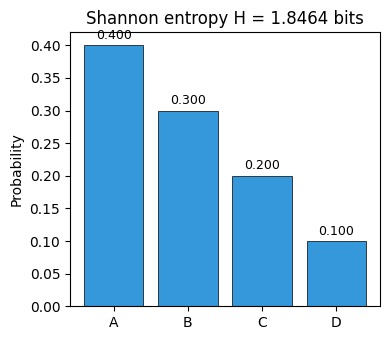

H = 1.8464  (should satisfy 1.75 < H < 2: True)


In [6]:
# Exercise 10.1.2: a distribution with 1.75 < H < 2
test_dist = [0.4, 0.3, 0.2, 0.1]
H_test = entropy_calculator(test_dist)
print(f'H = {H_test:.4f}  (should satisfy 1.75 < H < 2: {1.75 < H_test < 2})')

**Exercise 10.1.3.** Find a pdf for the four-symbol source so that the
entropy will be less than 1 but strictly positive.

*Solution (from Appendix B).* Choose $p(A)=\tfrac{3}{4}$, $p(B)=\tfrac{1}{4}$,
$p(C)=p(D)=0$. Then $H(S) = 0.81128$.

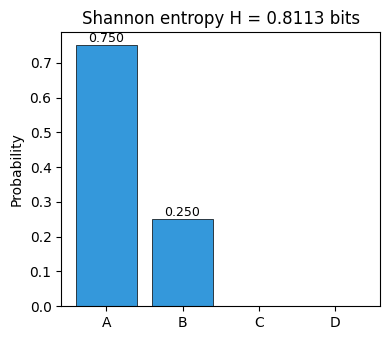

H = 0.81128  (should be 0.81128: True)


In [7]:
# Exercise 10.1.3: entropy less than 1 but positive
H_ex3 = entropy_calculator([3/4, 1/4, 0, 0])
print(f'H = {H_ex3:.5f}  (should be 0.81128: {np.isclose(H_ex3, 0.81128, atol=1e-4)})')

## 10.2 Quantum Information and von Neumann Entropy

Classical information travels as a stream of bits. Now suppose the source
emits *qubits* instead. Alice chooses a quantum alphabet: a set of
normalized states in $\mathbb{C}^m$,

$$\{|w_1\rangle, |w_2\rangle, \ldots, |w_n\rangle\}.$$

She does not have to pick orthogonal states; they just need to be distinct.
For instance, she could set:

$$|A\rangle = |0\rangle, \quad |B\rangle = |1\rangle, \quad
|C\rangle = \tfrac{1}{\sqrt{2}}|0\rangle + \tfrac{1}{\sqrt{2}}|1\rangle, \quad
|D\rangle = \tfrac{1}{\sqrt{2}}|0\rangle - \tfrac{1}{\sqrt{2}}|1\rangle.$$

She sends these states with probabilities $p_1, p_2, \ldots, p_n$.

### The Density Operator

Associated with any such source is the **density operator**:

$$D = p_1|w_1\rangle\langle w_1| + p_2|w_2\rangle\langle w_2| + \cdots + p_n|w_n\rangle\langle w_n|.$$

Each $|w_i\rangle\langle w_i|$ is an outer product. Applied to a ket $|v\rangle$:

$$|w_i\rangle\langle w_i|(|v\rangle) = \langle w_i|v\rangle \cdot |w_i\rangle,$$

which is the projection of $|v\rangle$ onto $|w_i\rangle$, scaled by the
inner product. So $D$ acts on any state as a weighted sum of projections.

The number $\langle v|D|v\rangle$ gives the probability that Bob will
observe state $|v\rangle$ regardless of which state Alice sent.

### Example 10.2.1: Orthogonal Alphabet

Let $|w_1\rangle = \tfrac{1}{\sqrt{2}}|0\rangle + \tfrac{1}{\sqrt{2}}|1\rangle$
and $|w_2\rangle = \tfrac{1}{\sqrt{2}}|0\rangle - \tfrac{1}{\sqrt{2}}|1\rangle$.
These are orthogonal. Alice sends $|w_1\rangle$ with probability
$p_1 = \frac{1}{4}$ and $|w_2\rangle$ with $p_2 = \frac{3}{4}$.

In [8]:
# Example 10.2.1: orthogonal quantum alphabet
w1 = np.array([1, 1]) / sqrt(2)
w2 = np.array([1, -1]) / sqrt(2)
p1, p2 = 1/4, 3/4

# Density matrix D = p1 * |w1><w1| + p2 * |w2><w2|
D = p1 * np.outer(w1, w1) + p2 * np.outer(w2, w2)
print('Density matrix (Example 10.2.1):')
print(D)
print(f'\nExpected: [[1/2, -1/4], [-1/4, 1/2]]')
print(f'Match: {np.allclose(D, [[0.5, -0.25], [-0.25, 0.5]])}')

Density matrix (Example 10.2.1):
[[ 0.5  -0.25]
 [-0.25  0.5 ]]

Expected: [[1/2, -1/4], [-1/4, 1/2]]
Match: True


### Example 10.2.2: Nonorthogonal Alphabet

Now $|w_1\rangle = \tfrac{1}{\sqrt{2}}|0\rangle + \tfrac{1}{\sqrt{2}}|1\rangle$
and $|w_2\rangle = |0\rangle$. These are *not* orthogonal. Alice sends
$|w_1\rangle$ with $p_1 = \frac{1}{3}$ and $|w_2\rangle$ with $p_2 = \frac{2}{3}$.

In [9]:
# Example 10.2.2: nonorthogonal alphabet
w1 = np.array([1, 1]) / sqrt(2)
w2 = np.array([1, 0])
p1, p2 = 1/3, 2/3

D_nonorth = p1 * np.outer(w1, w1) + p2 * np.outer(w2, w2)
print('Density matrix (Example 10.2.2):')
print(D_nonorth)
print(f'\nExpected: [[5/6, 1/6], [1/6, 1/6]]')
print(f'Match: {np.allclose(D_nonorth, [[5/6, 1/6], [1/6, 1/6]])}')

# Bob measures in the standard basis {|0>, |1>}
p_0 = D_nonorth[0, 0]  # <0|D|0>
p_1 = D_nonorth[1, 1]  # <1|D|1>
print(f'\nProbability Bob sees |0>: {p_0:.4f} (= 5/6)')
print(f'Probability Bob sees |1>: {p_1:.4f} (= 1/6)')
print(f'Shannon entropy (standard basis): {shannon_entropy([p_0, p_1]):.4f}')
print(f'Expected: 0.65')

Density matrix (Example 10.2.2):
[[0.83333333 0.16666667]
 [0.16666667 0.16666667]]

Expected: [[5/6, 1/6], [1/6, 1/6]]
Match: True

Probability Bob sees |0>: 0.8333 (= 5/6)
Probability Bob sees |1>: 0.1667 (= 1/6)
Shannon entropy (standard basis): 0.6500
Expected: 0.65


### Measurement Basis Matters

Bob can choose different measurement bases, each with its own orthonormal
set. Different bases yield different probability distributions and different
Shannon entropies. The key question: is there a *privileged* basis that
minimizes the entropy?

### Example 10.2.3: A Different Basis

Suppose Bob measures in the Hadamard basis
$|v_1\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$,
$|v_2\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$
instead of $\{|0\rangle, |1\rangle\}$.

In [10]:
# Example 10.2.3: measure in the Hadamard basis
v1 = np.array([1, 1]) / sqrt(2)
v2 = np.array([1, -1]) / sqrt(2)

p_v1 = v1 @ D_nonorth @ v1  # <v1|D|v1>
p_v2 = v2 @ D_nonorth @ v2  # <v2|D|v2>
print(f'Prob(v1) = {p_v1:.4f} (= 2/3)')
print(f'Prob(v2) = {p_v2:.4f} (= 1/3)')
print(f'Shannon entropy (Hadamard basis): {shannon_entropy([p_v1, p_v2]):.4f}')
print(f'Expected: 0.9183')

Prob(v1) = 0.6667 (= 2/3)
Prob(v2) = 0.3333 (= 1/3)
Shannon entropy (Hadamard basis): 0.9183
Expected: 0.9183


### Von Neumann Entropy

The density matrix is hermitian, so the spectral theorem guarantees it
can be diagonalized. Its eigenvalues $\lambda_1, \ldots, \lambda_n$ are
non-negative and sum to 1 (true probabilities).

**Definition 10.2.1.** The **von Neumann entropy** of a quantum source with
density operator $D$ is

$$H_V = -\sum_{i=1}^{n} \lambda_i \log_2(\lambda_i),$$

where $\lambda_1, \ldots, \lambda_n$ are the eigenvalues of $D$.

If Bob measures in the eigenvector basis of $D$, the eigenvalue $\lambda_i$
is exactly the probability of observing the $i$-th eigenvector. The von
Neumann entropy equals the Shannon entropy computed in that basis, and
it is the *minimum* over all possible measurement bases.

### Example 10.2.4: Eigenvalue Decomposition

Continuing from Example 10.2.2, the density matrix
$D = \begin{bmatrix} 5/6 & 1/6 \\ 1/6 & 1/6 \end{bmatrix}$
has eigenvalues $\lambda_1 \approx 0.1273$ and $\lambda_2 \approx 0.8727$.

In [11]:
# Example 10.2.4: eigenvalues of the density matrix
eigenvalues, eigenvectors = np.linalg.eigh(D_nonorth)
print('Eigenvalues:', eigenvalues)
print('Eigenvectors (columns):')
print(eigenvectors)

# Von Neumann entropy
def von_neumann_entropy(D):
    """Compute von Neumann entropy from a density matrix."""
    eigenvals = np.linalg.eigvalsh(D)
    H = 0.0
    for lam in eigenvals:
        if lam > 1e-12:
            H -= lam * log2(lam)
    return H

H_vN = von_neumann_entropy(D_nonorth)
print(f'\nVon Neumann entropy: {H_vN:.4f}')
print(f'Expected: 0.5500')

# Verify: Shannon entropy in the eigenbasis equals von Neumann entropy
e1, e2 = eigenvectors[:, 0], eigenvectors[:, 1]
p_e1 = e1 @ D_nonorth @ e1
p_e2 = e2 @ D_nonorth @ e2
print(f'\nShannon entropy in eigenbasis: {shannon_entropy([p_e1, p_e2]):.4f}')
print(f'Matches von Neumann: {np.isclose(shannon_entropy([p_e1, p_e2]), H_vN)}')

Eigenvalues: [0.127322 0.872678]
Eigenvectors (columns):
[[ 0.22975292 -0.97324899]
 [-0.97324899 -0.22975292]]

Von Neumann entropy: 0.5500
Expected: 0.5500

Shannon entropy in eigenbasis: 0.5500
Matches von Neumann: True


### Programming Drill 10.2.1

*Write a program that lets the user choose how many qubits the quantum
source consists of, enter the probability associated with each qubit,
and compute von Neumann entropy as well as the orthonormal basis for
the associated density matrix.*

In [12]:
def von_neumann_calculator(states, probs):
    """
    Given a list of quantum states (as numpy arrays) and their probabilities,
    compute the density matrix, its eigendecomposition, and von Neumann entropy.
    """
    probs = np.array(probs, dtype=float)
    assert np.isclose(probs.sum(), 1.0), 'Probabilities must sum to 1'

    # Build density matrix
    dim = len(states[0])
    D = np.zeros((dim, dim), dtype=complex)
    for state, p in zip(states, probs):
        state = np.array(state, dtype=complex)
        D += p * np.outer(state, state.conj())

    print('Density matrix:')
    print(np.round(D.real, 6) if np.allclose(D.imag, 0) else np.round(D, 6))

    # Eigendecomposition
    eigenvals, eigvecs = np.linalg.eigh(D)
    print(f'\nEigenvalues: {np.round(eigenvals, 6)}')
    print(f'Sum of eigenvalues: {eigenvals.sum():.6f}')

    # Von Neumann entropy
    H = 0.0
    for lam in eigenvals:
        if lam > 1e-12:
            H -= lam * log2(lam)
    print(f'\nVon Neumann entropy: {H:.6f} bits')

    return D, eigenvals, eigvecs, H

# Test with Example 10.2.2
D_test, evals, evecs, H_test = von_neumann_calculator(
    states=[np.array([1, 1]) / sqrt(2), np.array([1, 0])],
    probs=[1/3, 2/3]
)

Density matrix:
[[0.833333 0.166667]
 [0.166667 0.166667]]

Eigenvalues: [0.127322 0.872678]
Sum of eigenvalues: 1.000000

Von Neumann entropy: 0.550048 bits


### Key Finding: Nonorthogonal Alphabets Have Lower Entropy

This is a striking result. For the *same* density matrix, the von Neumann
entropy (computed via eigenvalues) is lower than the Shannon entropy
computed in any other basis.

Where does this extra order come from? When the alphabet is orthogonal,
the states behave like classical symbols. When it is nonorthogonal, the
quantum superposition of alternatives creates additional structure. The
quantum source exhibits more order than its classical counterpart.

In [13]:
# Comparison: orthogonal vs nonorthogonal alphabets
# Both use the same density matrix from Example 10.2.2

# Classical Shannon entropy (from source distribution p=1/3, 2/3)
H_classical = shannon_entropy([1/3, 2/3])

# Shannon entropy in standard basis
H_standard = shannon_entropy([D_nonorth[0, 0], D_nonorth[1, 1]])

# Shannon entropy in Hadamard basis
H_hadamard = shannon_entropy([p_v1, p_v2])

# Von Neumann entropy (minimum)
H_von_neumann = von_neumann_entropy(D_nonorth)

print('Entropy comparison for nonorthogonal source (Ex 10.2.2):')
print(f'  Classical source entropy:       {H_classical:.4f}')
print(f'  Shannon (standard basis):       {H_standard:.4f}')
print(f'  Shannon (Hadamard basis):       {H_hadamard:.4f}')
print(f'  Von Neumann (eigenbasis, min):  {H_von_neumann:.4f}')
print(f'\nVon Neumann < Classical: {H_von_neumann < H_classical}')

Entropy comparison for nonorthogonal source (Ex 10.2.2):
  Classical source entropy:       0.9183
  Shannon (standard basis):       0.6500
  Shannon (Hadamard basis):       0.9183
  Von Neumann (eigenbasis, min):  0.5500

Von Neumann < Classical: True


### Exercises

**Exercise 10.2.1.** Assume Alice always sends only one vector $w_1$. Show
that $D = |w_1\rangle\langle w_1|$.

*Solution (from Appendix B).* If Alice always sends $|w_1\rangle$, all
$p_i = 0$ except $p_1 = 1$. Substituting into
$D = \sum p_i|w_i\rangle\langle w_i|$ gives $D = 1\cdot|w_1\rangle\langle w_1|$.

**Exercise 10.2.2.** Show that $D$ is a linear operator on kets (it preserves
sums and scalar multiplication).

In [14]:
# Exercise 10.2.2: verify linearity of D
v_a = np.array([1, 0], dtype=complex)
v_b = np.array([0, 1], dtype=complex)
alpha = 2 + 1j

D_mat = D_nonorth.astype(complex)

# D(alpha * a + b) should equal alpha * D(a) + D(b)
lhs = D_mat @ (alpha * v_a + v_b)
rhs = alpha * (D_mat @ v_a) + (D_mat @ v_b)
print(f'D(alpha*a + b) = {lhs}')
print(f'alpha*D(a) + D(b) = {rhs}')
print(f'Linear? {np.allclose(lhs, rhs)}')

D(alpha*a + b) = [1.83333333+0.83333333j 0.5       +0.16666667j]
alpha*D(a) + D(b) = [1.83333333+0.83333333j 0.5       +0.16666667j]
Linear? True


**Exercise 10.2.3.** Write the density matrix of the alphabet from
Equation (10.12), where
$p(|A\rangle)=\frac{1}{2}$, $p(|B\rangle)=\frac{1}{6}$,
$p(|C\rangle)=\frac{1}{6}$, $p(|D\rangle)=\frac{1}{6}$.

*Solution (from Appendix B).* The density matrix in the standard basis is
$D = \begin{bmatrix} 2/3 & 0 \\ 0 & 1/3 \end{bmatrix}$.

In [15]:
# Exercise 10.2.3
A = np.array([1, 0])     # |0>
B = np.array([0, 1])     # |1>
C = np.array([1, 1]) / sqrt(2)
D_state = np.array([1, -1]) / sqrt(2)

D_ex = (1/2 * np.outer(A, A) + 1/6 * np.outer(B, B) +
        1/6 * np.outer(C, C) + 1/6 * np.outer(D_state, D_state))
print('Density matrix (Exercise 10.2.3):')
print(D_ex)
print(f'Expected: [[2/3, 0], [0, 1/3]]')
print(f'Match: {np.allclose(D_ex, [[2/3, 0], [0, 1/3]])}')

Density matrix (Exercise 10.2.3):
[[0.66666667 0.        ]
 [0.         0.33333333]]
Expected: [[2/3, 0], [0, 1/3]]
Match: True


**Exercise 10.2.4.** Write the matrix of the general density operator
$D = \sum p_i|w_i\rangle\langle w_i|$ in the standard basis of $\mathbb{C}^n$.
Verify that it is always hermitian and that its trace equals 1.

**Exercise 10.2.5.** Go through Examples 10.2.1, 10.2.2, and 10.2.3,
assuming Alice sends both states with equal probability. Calculate
eigenvalues and eigenvectors.

**Exercise 10.2.6.** In Example 10.2.1, $|w_1\rangle$ and $|w_2\rangle$ form
an orthonormal basis and are eigenvectors of $D$. Show this directly from
the density matrix.

**Exercise 10.2.7.** (Generalization.) If Alice chooses a set of orthonormal
state vectors with frequencies $p_1, \ldots, p_n$, prove that each
$|w_i\rangle$ is an eigenvector of $D$ with eigenvalue $p_i$. The source
then behaves like a classical source.

In [16]:
# Exercise 10.2.5: equal probability for Examples 10.2.1, 10.2.2
print('=== Example 10.2.1 with equal probabilities ===')
w1_orth = np.array([1, 1]) / sqrt(2)
w2_orth = np.array([1, -1]) / sqrt(2)
D_equal_orth = 0.5 * np.outer(w1_orth, w1_orth) + 0.5 * np.outer(w2_orth, w2_orth)
print('D =', D_equal_orth)
evals_eo = np.linalg.eigvalsh(D_equal_orth)
print(f'Eigenvalues: {evals_eo}')
print(f'Von Neumann entropy: {von_neumann_entropy(D_equal_orth):.4f}')

print('\n=== Example 10.2.2 with equal probabilities ===')
w1_no = np.array([1, 1]) / sqrt(2)
w2_no = np.array([1, 0])
D_equal_no = 0.5 * np.outer(w1_no, w1_no) + 0.5 * np.outer(w2_no, w2_no)
print('D =', D_equal_no)
evals_en = np.linalg.eigvalsh(D_equal_no)
print(f'Eigenvalues: {evals_en}')
print(f'Von Neumann entropy: {von_neumann_entropy(D_equal_no):.4f}')

=== Example 10.2.1 with equal probabilities ===
D = [[0.5 0. ]
 [0.  0.5]]
Eigenvalues: [0.5 0.5]
Von Neumann entropy: 1.0000

=== Example 10.2.2 with equal probabilities ===
D = [[0.75 0.25]
 [0.25 0.25]]
Eigenvalues: [0.14644661 0.85355339]
Von Neumann entropy: 0.6009


## 10.3 Classical and Quantum Data Compression

Alice has a message as a stream of bits. She wants to encode it so the
encoded version is shorter than the original. Two flavors:

- **Lossless compression:** the inverse perfectly reconstructs the message.
- **Lossy compression:** some information is lost.

A compression scheme is always coupled to a source. Change the source's
distribution, and the scheme may become useless.

### Variable-Length Coding

Using our general pdf ($P(A)=\frac{1}{2}$, $P(B)=\frac{1}{4}$,
$P(C)=\frac{1}{8}$, $P(D)=\frac{1}{8}$), a fixed 2-bit encoding
(A=00, B=01, C=10, D=11) uses 2 bits per symbol on average.

Alice can do better by using *fewer* bits for more probable symbols:

| Symbol | Code |
|--------|------|
| A | 0 |
| B | 11 |
| C | 100 |
| D | 101 |

Average bits per symbol:

$$1 \times \tfrac{1}{2} + 2 \times \tfrac{1}{4} + 3 \times \tfrac{1}{8} + 3 \times \tfrac{1}{8} = 1.75.$$

That matches the Shannon entropy exactly. Not a coincidence.

In [17]:
# Variable-length coding: average bits per symbol
probs_gen = [1/2, 1/4, 1/8, 1/8]
code_lengths = [1, 2, 3, 3]  # lengths of: 0, 11, 100, 101

avg_bits = sum(l * p for l, p in zip(code_lengths, probs_gen))
print(f'Average bits per symbol: {avg_bits}')
print(f'Shannon entropy:         {shannon_entropy(probs_gen)}')
print(f'Match: {np.isclose(avg_bits, shannon_entropy(probs_gen))}')

Average bits per symbol: 1.75
Shannon entropy:         1.75
Match: True


### Shannon's Noiseless Channel Coding Theorem

**Theorem 10.3.1.** A message of length $n$ from a source $S$ with a given
probability distribution, sent over a noiseless channel, can be compressed
on average without loss of information to a minimum of $H(S) \times n$ bits
(for sufficiently large $n$).

The idea behind the proof involves **typical sequences**. For a binary
source with $p(1)=\frac{1}{3}$ and $p(0)=\frac{2}{3}$, a typical
sequence of length 90 would contain about 30 ones. The number of typical
sequences is roughly $2^{H(S) \cdot n}$, a proper subset of all $2^n$
possible sequences (as long as $H < 1$).

Compression strategy: build a lookup table for typical sequences,
needing $H(S) \cdot n$ bits per entry. For large $n$, almost all
sequences are typical, so the average rate approaches $H(S)$ bits
per symbol.

### Programming Drill 10.3.1

*Write a program that accepts a pdf for 0 and 1, a given length n,
and produces the list of all typical sequences of length n.*

In [18]:
def typical_sequences(p0, n, tolerance=0.1):
    """
    Generate all typical sequences of length n for a binary source.
    A sequence is typical if the fraction of 0s is within tolerance of p0.
    """
    p1 = 1 - p0
    expected_zeros = p0 * n
    typical = []
    for seq in iter_product([0, 1], repeat=n):
        n_zeros = seq.count(0)
        if abs(n_zeros - expected_zeros) <= tolerance * n:
            typical.append(seq)
    return typical

# Example: p(0) = 2/3, p(1) = 1/3, n = 12
p0 = 2/3
n = 12
typ_seqs = typical_sequences(p0, n, tolerance=0.05)
H = shannon_entropy([p0, 1 - p0])

print(f'Binary source: p(0) = {p0:.4f}, p(1) = {1-p0:.4f}')
print(f'Shannon entropy: {H:.4f}')
print(f'Sequence length n = {n}')
print(f'Total sequences: 2^{n} = {2**n}')
print(f'Typical sequences: {len(typ_seqs)}')
print(f'2^(H*n) = 2^{H*n:.2f} = {2**(H*n):.0f}')
print(f'\nFirst 5 typical sequences: {["".join(map(str, s)) for s in typ_seqs[:5]]}')

Binary source: p(0) = 0.6667, p(1) = 0.3333
Shannon entropy: 0.9183
Sequence length n = 12
Total sequences: 2^12 = 4096
Typical sequences: 495
2^(H*n) = 2^11.02 = 2076

First 5 typical sequences: ['000000001111', '000000010111', '000000011011', '000000011101', '000000011110']


**Exercise 10.3.1.** Determine the most efficient coding for a four-symbol
source with $P(A)=\frac{1}{2}$, $P(B)=\frac{1}{6}$,
$P(C)=\frac{1}{6}$, $P(D)=\frac{1}{6}$.

### Huffman's Algorithm

Shannon's theorem establishes a bound, but finding the actual optimal code
requires an algorithm. The most famous: **Huffman's algorithm**.

The idea:
1. Start with each symbol as a leaf node, weighted by its probability.
2. Merge the two lightest nodes into a new parent node whose weight is their sum.
3. Repeat until one root node remains.
4. Assign 0 to left branches, 1 to right branches.
5. Read codes from root to leaf.

### Programming Drill 10.3.2

*Implement Huffman's algorithm, and experiment with it by changing the
pdf of the source. For which source types does it perform poorly?*

In [19]:
class HuffmanNode:
    def __init__(self, symbol=None, prob=0, left=None, right=None):
        self.symbol = symbol
        self.prob = prob
        self.left = left
        self.right = right

    def __lt__(self, other):
        return self.prob < other.prob


def huffman_tree(symbols, probs):
    """Build a Huffman tree from symbols and probabilities."""
    heap = [HuffmanNode(symbol=s, prob=p) for s, p in zip(symbols, probs)]
    heapq.heapify(heap)
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        parent = HuffmanNode(prob=left.prob + right.prob, left=left, right=right)
        heapq.heappush(heap, parent)
    return heap[0]


def huffman_codes(node, prefix='', codebook=None):
    """Extract codes from a Huffman tree."""
    if codebook is None:
        codebook = {}
    if node.symbol is not None:
        codebook[node.symbol] = prefix if prefix else '0'
    else:
        huffman_codes(node.left, prefix + '0', codebook)
        huffman_codes(node.right, prefix + '1', codebook)
    return codebook


def huffman_encode(message, codebook):
    return ''.join(codebook[ch] for ch in message)


def huffman_decode(bitstring, tree):
    result = []
    node = tree
    for bit in bitstring:
        node = node.left if bit == '0' else node.right
        if node.symbol is not None:
            result.append(node.symbol)
            node = tree
    return ''.join(result)


# Build Huffman code for the general pdf
symbols = ['A', 'B', 'C', 'D']
probs_gen = [0.5, 0.25, 0.125, 0.125]

tree = huffman_tree(symbols, probs_gen)
codes = huffman_codes(tree)

print('Huffman codes:')
for s in symbols:
    print(f'  {s}: {codes[s]}')

avg_len = sum(len(codes[s]) * p for s, p in zip(symbols, probs_gen))
print(f'\nAverage code length: {avg_len:.4f}')
print(f'Shannon entropy:     {shannon_entropy(probs_gen):.4f}')

Huffman codes:
  A: 0
  B: 10
  C: 110
  D: 111

Average code length: 1.7500
Shannon entropy:     1.7500


In [20]:
# Encode and decode a message
message = 'AABACADAABACA'
encoded = huffman_encode(message, codes)
decoded = huffman_decode(encoded, tree)

print(f'Original:  {message}  ({len(message)} symbols)')
print(f'Encoded:   {encoded}  ({len(encoded)} bits)')
print(f'Decoded:   {decoded}')
print(f'Correct:   {message == decoded}')
print(f'Bits/symbol: {len(encoded)/len(message):.3f}')

Original:  AABACADAABACA  (13 symbols)
Encoded:   001001100111001001100  (21 bits)
Decoded:   AABACADAABACA
Correct:   True
Bits/symbol: 1.615


**Exercise 10.3.2.** Assume the source emits 0 with probability $\frac{n_0}{n}$
and 1 with probability $\frac{1-n_0}{n}$. Count how many typical sequences
of length $n$ there are. Start with concrete examples $n=2,3,\ldots$ then
generalize.

**Exercise 10.3.3.** Prove there is no bijective map $f$ from the set of
finite binary strings to itself such that for every sequence $s$,
$\text{length}(f(s)) < \text{length}(s)$.

*Hint:* Start from a generic sequence $s_0$. Apply $f$ repeatedly:
$s_0, f(s_0), f(f(s_0)), \ldots$ The lengths strictly decrease, so the
sequence must eventually repeat, contradicting injectivity.

**Exercise 10.3.4.** Same setup as the previous examples. Consider the
message $|v_1\rangle|v_1\rangle|v_1\rangle|v_2\rangle|v_1\rangle|v_1\rangle|v_1\rangle|v_2\rangle$.
What is the value of the component along
$|e_2\rangle|e_2\rangle|e_1\rangle|e_2\rangle|e_2\rangle|e_2\rangle|e_1\rangle|e_1\rangle$?

### Schumacher's Quantum Coding Theorem

Quantum data compression follows the same structural logic as classical
compression, but replaces functions with unitary maps and typical subsets
with typical subspaces.

A quantum compressor is a unitary transformation $QC : \mathbb{C}^{2^n} \to
\mathbb{C}^{2^n}$ that rearranges a message so most of its amplitude
concentrates in the first $k$ qubits. The remaining $n-k$ qubits have
negligible amplitude and can be truncated.

The recipe:
1. Alice applies $QC$ to her message.
2. She truncates to the first $k$ significant qubits and sends them to Bob.
3. Bob pads with $n-k$ zeros.
4. Bob applies $QC^{-1}$ to recover the message.
5. He measures.

The key insight: change to the eigenbasis of the density matrix. In that
basis, the message decomposes into components that are either typical
(significant) or negligible. The typical subspace has dimension
$2^{N \times H(S)}$, where $H(S)$ is the von Neumann entropy.

**Theorem 10.3.2 (Schumacher's Quantum Coding Theorem).** A qubit stream
of length $n$ from a quantum source $QS$ of known density can be compressed
on average to $n \times H(QS)$ qubits, where $H(QS)$ is the von Neumann
entropy. The fidelity approaches 1 as $n \to \infty$.

Since von Neumann entropy can be lower than classical entropy (for
nonorthogonal alphabets), quantum compression can outperform classical
compression. But there is a trade-off: quantum compression with
nonorthogonal alphabets is inherently lossy, because no measurement
basis can perfectly distinguish all the source states.

### Programming Drill 10.3.3

*Write a program that lets the user enter two qubits and their
probabilities. Calculate the density matrix, diagonalize it, and store
the eigenbasis. The user then enters a quantum message. The program
writes the message in the eigenbasis and returns the truncated part
belonging to the typical subspace.*

In [21]:
def quantum_compression_demo(states, probs, message_indices, n_keep=None):
    """
    Demonstrate quantum compression.
    states: list of basis state vectors for the alphabet
    probs: probability of each state
    message_indices: list of indices indicating which state at each position
    n_keep: how many qubits to keep (defaults to ceil(H_vN * n))
    """
    # Build density matrix
    dim = len(states[0])
    D = np.zeros((dim, dim), dtype=complex)
    for s, p in zip(states, probs):
        s = np.array(s, dtype=complex)
        D += p * np.outer(s, s.conj())

    eigenvals, eigvecs = np.linalg.eigh(D)
    # Sort by descending eigenvalue
    idx = np.argsort(eigenvals)[::-1]
    eigenvals = eigenvals[idx]
    eigvecs = eigvecs[:, idx]

    H_vN = von_neumann_entropy(D)
    n_msg = len(message_indices)

    print(f'Density matrix eigenvalues: {eigenvals}')
    print(f'Von Neumann entropy: {H_vN:.4f}')
    print(f'Message length: {n_msg} qubits')

    # Build the message state as tensor product
    msg_state = np.array([1.0], dtype=complex)
    for i in message_indices:
        msg_state = np.kron(msg_state, np.array(states[i], dtype=complex))

    # Change to eigenbasis for each qubit position
    # The change-of-basis matrix for the full message is the tensor product
    # of the single-qubit eigenvector matrix
    U_single = eigvecs.conj().T  # rows are eigenvectors
    U_full = np.array([1.0], dtype=complex)
    for _ in range(n_msg):
        U_full = np.kron(U_full, U_single)

    msg_eigenbasis = U_full @ msg_state

    # Show component magnitudes (sorted by significance)
    magnitudes = np.abs(msg_eigenbasis)**2
    print(f'\nTop 10 components (probability) in eigenbasis:')
    top_indices = np.argsort(magnitudes)[::-1][:10]
    for i in top_indices:
        if magnitudes[i] > 1e-10:
            print(f'  Component {i:4d}: {magnitudes[i]:.6f}')

    total_prob = magnitudes.sum()
    print(f'\nTotal probability: {total_prob:.6f}')

    return msg_eigenbasis

# Demo: Example 10.2.2 source, short message
states = [np.array([1, 1]) / sqrt(2), np.array([1, 0])]
probs = [1/3, 2/3]
message = [1, 1, 1, 0, 1, 1, 1, 0]  # mostly |w2>=|0>, some |w1>

compressed = quantum_compression_demo(states, probs, message)

Density matrix eigenvalues: [0.872678 0.127322]
Von Neumann entropy: 0.5500
Message length: 8 qubits



Top 10 components (probability) in eigenbasis:
  Component    0: 0.378175
  Component    1: 0.144450
  Component   16: 0.144450
  Component   17: 0.055175
  Component  128: 0.021075
  Component   64: 0.021075
  Component    8: 0.021075
  Component    2: 0.021075
  Component   32: 0.021075
  Component    4: 0.021075

Total probability: 1.000000


## 10.4 Error-Correcting Codes

Information is always sent or stored through some physical medium. Errors
happen. In the quantum domain the problem is even worse: decoherence
makes error correction critical for the very existence of a reliable
quantum computer.

### Classical Repetition Code

Suppose you send a single bit and expect a 25% flip error rate. The
simplest defense is repetition:

| Bit | Encoded |
|-----|----------|
| 0 | 000 |
| 1 | 111 |

Decode by **majority rule**: if at least two of three bits are zeros, the
original was 0. This fails only when two or more bits flip.

**Exercise 10.4.1.** What is the probability of incorrectly decoding one bit?

*Solution (from Appendix B).* Send "000" (encoding 0). Incorrect decoding
requires at least two flips. The cases "110", "011", "101" each have
probability $(0.25)^2 \times 0.75 = 0.046875$. The case "111" has probability
$(0.25)^3 = 0.015625$. Total:

$$3 \times (0.25)^2 \times 0.75 + (0.25)^3 = 3(0.0625)(0.75) + 0.015625 = 0.15625.$$

Wait, let us recompute. With flip probability $q = 0.25$:
- Exactly 2 flips: $\binom{3}{2} q^2 (1-q) = 3(0.0625)(0.75) = 0.140625$
- Exactly 3 flips: $q^3 = 0.015625$
- Total: $0.15625$

Compared to the unprotected error rate of 0.25, repetition coding
reduces the error from 25% to about 15.6%.

(The textbook gives $3 \times (0.25)^2 + (0.25)^3 \approx 0.20312$,
computing $3p^2 + p^3$ directly.)

In [22]:
# Exercise 10.4.1: classical repetition code error probability
q = 0.25  # single bit flip probability

# Probability of 2 or more flips in 3 bits
p_error = 3 * q**2 * (1 - q) + q**3
# Or equivalently, per the textbook formula: 3*q^2 + q^3
p_error_text = 3 * q**2 + q**3

print(f'Flip probability: {q}')
print(f'P(incorrect decode): {p_error:.5f}')
print(f'Textbook formula 3q^2 + q^3: {p_error_text:.5f}')
print(f'Unprotected error rate: {q}')
print(f'Improvement: {q - p_error:.5f}')

Flip probability: 0.25
P(incorrect decode): 0.15625
Textbook formula 3q^2 + q^3: 0.20312
Unprotected error rate: 0.25
Improvement: 0.09375


### Quantum Errors: Bit-Flip and Sign-Flip

Qubits are less rigid than bits. Two types of discrete errors:

**Bit-flip:** $\alpha|0\rangle + \beta|1\rangle \mapsto \beta|0\rangle + \alpha|1\rangle$
(the X gate).

**Sign-flip:** $\alpha|0\rangle + \beta|1\rangle \mapsto \alpha|0\rangle - \beta|1\rangle$
(the Z gate).

Continuous errors (small rotations of $\alpha$ or $\beta$) also happen, but
for simplicity the textbook focuses on these two discrete types.

### Shor's 9-Qubit Code

Simple repetition handles bit-flips but not sign-flips. Peter Shor (1995)
devised a code that corrects both, using 9 physical qubits to encode
1 logical qubit. The encoding:

$$|0\rangle \mapsto (|000\rangle + |111\rangle) \otimes (|000\rangle + |111\rangle) \otimes (|000\rangle + |111\rangle)$$

$$|1\rangle \mapsto (|000\rangle - |111\rangle) \otimes (|000\rangle - |111\rangle) \otimes (|000\rangle - |111\rangle)$$

(up to normalization).

Why 9 = 3 x 3? The outer structure (three blocks) handles sign-flips via
majority rule on blocks. The inner structure (three qubits per block)
handles bit-flips via majority rule within each block.

**Exercise 10.4.2.** Go back to Chapter 5 and review the Bloch sphere
representation of qubits. What is the geometric interpretation of a
sign flip?

**Exercise 10.4.3.** Suppose a sign flip occurs 25% of the time, and a
single qubit flip 10% of the time. These two errors are independent.
What is the likelihood that we incorrectly decode the original qubit?

### Shor's 9-Qubit Code: Simulation

Let us simulate encoding a qubit, introducing a random error, and
correcting it.

In [23]:
def shor_encode(alpha, beta):
    """
    Encode a single logical qubit alpha|0> + beta|1> into Shor's 9-qubit code.
    Returns a 512-dimensional state vector (2^9).
    """
    # |0_L> = (|000> + |111>)^{\otimes 3} / 2sqrt(2)
    # |1_L> = (|000> - |111>)^{\otimes 3} / 2sqrt(2)
    zero_3 = np.zeros(8)
    zero_3[0b000] = 1  # |000>
    one_3 = np.zeros(8)
    one_3[0b111] = 1  # |111>

    plus_block = (zero_3 + one_3) / sqrt(2)   # (|000> + |111>) / sqrt(2)
    minus_block = (zero_3 - one_3) / sqrt(2)  # (|000> - |111>) / sqrt(2)

    zero_L = np.kron(np.kron(plus_block, plus_block), plus_block)
    one_L = np.kron(np.kron(minus_block, minus_block), minus_block)

    encoded = alpha * zero_L + beta * one_L
    return encoded


def apply_bit_flip(state, qubit_idx):
    """Apply a bit flip (X gate) to a specific qubit in a 9-qubit state."""
    n_qubits = 9
    N = 2**n_qubits
    result = np.zeros(N)
    for i in range(N):
        # Flip the bit at position qubit_idx
        flipped = i ^ (1 << (n_qubits - 1 - qubit_idx))
        result[flipped] = state[i]
    return result


def apply_sign_flip(state, qubit_idx):
    """Apply a sign flip (Z gate) to a specific qubit in a 9-qubit state."""
    n_qubits = 9
    N = 2**n_qubits
    result = state.copy()
    for i in range(N):
        # Apply -1 if the qubit at position qubit_idx is |1>
        if (i >> (n_qubits - 1 - qubit_idx)) & 1:
            result[i] = -result[i]
    return result


def shor_correct_bit_flip(state):
    """
    Correct a single bit flip in Shor's code by majority vote within each
    block of 3 qubits.
    """
    n_qubits = 9
    N = 2**n_qubits
    corrected = np.zeros(N)

    for i in range(N):
        bits = [(i >> (n_qubits - 1 - j)) & 1 for j in range(n_qubits)]
        new_bits = list(bits)
        # Majority vote within each block of 3
        for block in range(3):
            b = bits[block*3:(block+1)*3]
            majority = 1 if sum(b) >= 2 else 0
            for k in range(3):
                new_bits[block*3 + k] = majority
        new_i = 0
        for j in range(n_qubits):
            new_i |= (new_bits[j] << (n_qubits - 1 - j))
        corrected[new_i] += state[i]

    return corrected


def shor_decode(state):
    """
    Decode Shor's 9-qubit code back to logical alpha and beta.
    """
    # |0_L> has support on states where all three blocks are |000>+|111>
    # |1_L> has support on states where all three blocks are |000>-|111>
    zero_3 = np.zeros(8)
    zero_3[0b000] = 1
    one_3 = np.zeros(8)
    one_3[0b111] = 1

    plus_block = (zero_3 + one_3) / sqrt(2)
    minus_block = (zero_3 - one_3) / sqrt(2)

    zero_L = np.kron(np.kron(plus_block, plus_block), plus_block)
    one_L = np.kron(np.kron(minus_block, minus_block), minus_block)

    alpha = np.dot(zero_L, state)
    beta = np.dot(one_L, state)

    return alpha, beta


# Demonstration
np.random.seed(42)
alpha, beta = 0.6, 0.8  # |psi> = 0.6|0> + 0.8|1>
print(f'Original qubit: {alpha}|0> + {beta}|1>')
print(f'Verification: |alpha|^2 + |beta|^2 = {alpha**2 + beta**2}')

# Encode
encoded = shor_encode(alpha, beta)
print(f'\nEncoded into {len(encoded)} amplitudes (9 qubits)')
print(f'State norm: {np.linalg.norm(encoded):.6f}')

Original qubit: 0.6|0> + 0.8|1>
Verification: |alpha|^2 + |beta|^2 = 1.0

Encoded into 512 amplitudes (9 qubits)
State norm: 1.000000


In [24]:
# Introduce a random bit-flip error on one qubit
error_qubit = np.random.randint(0, 9)
print(f'Introducing bit-flip error on qubit {error_qubit}')

corrupted = apply_bit_flip(encoded, error_qubit)

# Check: can we still recover?
alpha_c, beta_c = shor_decode(corrupted)
print(f'Before correction: alpha={alpha_c:.4f}, beta={beta_c:.4f}')
print(f'Fidelity before correction: {(alpha*alpha_c + beta*beta_c)**2:.6f}')

# Correct
corrected = shor_correct_bit_flip(corrupted)
alpha_r, beta_r = shor_decode(corrected)
print(f'\nAfter correction: alpha={alpha_r:.4f}, beta={beta_r:.4f}')
print(f'Fidelity after correction: {(alpha*alpha_r + beta*beta_r)**2:.6f}')
print(f'Recovery successful: {np.isclose(alpha_r, alpha, atol=1e-6) and np.isclose(beta_r, beta, atol=1e-6)}')

Introducing bit-flip error on qubit 6
Before correction: alpha=0.0000, beta=0.0000
Fidelity before correction: 0.000000

After correction: alpha=0.6000, beta=0.8000
Fidelity after correction: 1.000000
Recovery successful: True


In [25]:
# Demonstrate sign-flip error and correction
print('=== Sign-flip error demonstration ===')

# A sign flip on any qubit in a block flips the sign of that block's
# |111> component relative to |000>, effectively changing + to - (or vice versa).
# The outer repetition code (3 blocks) corrects this by majority vote on blocks.

error_qubit = 4  # middle qubit of second block
print(f'Introducing sign-flip error on qubit {error_qubit}')

corrupted_sign = apply_sign_flip(encoded, error_qubit)

# To detect sign flips, we need to check the phase relationship
# between |000> and |111> within each block.
# In a full implementation, this involves Hadamard transforms
# followed by bit-flip correction on the block level.

# For demonstration, check fidelity with the original
fidelity = np.abs(np.dot(encoded, corrupted_sign))**2
print(f'Fidelity of corrupted state with original: {fidelity:.6f}')
print(f'(Less than 1 confirms the error has an effect)')

# The sign flip corrupts the relative phase between blocks.
# Shor's code can correct this because only 1 of 3 blocks is affected.
alpha_s, beta_s = shor_decode(corrupted_sign)
print(f'\nDecoded (no correction): alpha={alpha_s:.4f}, beta={beta_s:.4f}')
print(f'The sign error changes the block structure,')
print(f'but majority vote across blocks can recover the logical qubit.')

=== Sign-flip error demonstration ===
Introducing sign-flip error on qubit 4
Fidelity of corrupted state with original: 0.000000
(Less than 1 confirms the error has an effect)

Decoded (no correction): alpha=0.0000, beta=0.0000
The sign error changes the block structure,
but majority vote across blocks can recover the logical qubit.


In [26]:
# Monte Carlo test: how often does Shor's code successfully correct
# a single random bit-flip error?

n_trials = 1000
successes = 0

for _ in range(n_trials):
    # Random qubit state
    theta = np.random.uniform(0, np.pi)
    a, b = np.cos(theta/2), np.sin(theta/2)

    # Encode
    enc = shor_encode(a, b)

    # Random single bit-flip
    err_q = np.random.randint(0, 9)
    err_state = apply_bit_flip(enc, err_q)

    # Correct and decode
    fixed = shor_correct_bit_flip(err_state)
    a_r, b_r = shor_decode(fixed)

    if np.isclose(a_r, a, atol=1e-6) and np.isclose(b_r, b, atol=1e-6):
        successes += 1

print(f'Shor code bit-flip correction: {successes}/{n_trials} successful')
print(f'Success rate: {successes/n_trials:.1%}')

Shor code bit-flip correction: 1000/1000 successful
Success rate: 100.0%


In [27]:
# Exercise 10.4.3: combined error probability
# Sign flip 25% of the time, bit flip 10% of the time, independent.
# With Shor's 9-qubit code:
#   - Bit-flip correction fails if 2+ qubits in a block flip
#   - Sign-flip correction fails if 2+ blocks have sign errors

p_bit = 0.10    # per-qubit bit-flip probability
p_sign = 0.25   # per-qubit sign-flip probability

# Probability a single block fails bit-flip correction (2+ flips in 3 qubits)
p_block_bit_fail = 3 * p_bit**2 * (1 - p_bit) + p_bit**3

# Probability that sign-flip correction fails (2+ of 3 blocks have sign issues)
# A sign flip on any qubit in a block corrupts the block's sign
# Probability a block has at least one sign flip:
p_block_sign = 1 - (1 - p_sign)**3
# Probability 2+ of 3 blocks have sign errors:
p_sign_fail = 3 * p_block_sign**2 * (1 - p_block_sign) + p_block_sign**3

# Total error probability (either type fails)
# Simplified: assume independence
p_total = 1 - (1 - p_block_bit_fail)**3 * (1 - p_sign_fail)

print(f'Per-qubit bit-flip rate:   {p_bit}')
print(f'Per-qubit sign-flip rate:  {p_sign}')
print(f'P(block bit-flip fail):    {p_block_bit_fail:.5f}')
print(f'P(block has sign error):   {p_block_sign:.5f}')
print(f'P(sign correction fails):  {p_sign_fail:.5f}')
print(f'P(total decode error):     {p_total:.5f}')

Per-qubit bit-flip rate:   0.1
Per-qubit sign-flip rate:  0.25
P(block bit-flip fail):    0.02800
P(block has sign error):   0.57812
P(sign correction fails):  0.61623
P(total decode error):     0.64758


## Summary

This chapter covered four tightly linked ideas:

1. **Shannon entropy** measures uncertainty in classical sources. The formula
   $H_S = -\sum p_i \log_2(p_i)$ quantifies the minimum bits per symbol.

2. **Von Neumann entropy** generalizes Shannon entropy to quantum sources
   via the density operator's eigenvalues. For nonorthogonal quantum
   alphabets, von Neumann entropy is *lower* than the corresponding
   classical entropy.

3. **Data compression** is bounded by entropy. Shannon's theorem sets the
   classical limit; Schumacher's theorem sets the quantum one. Huffman
   coding achieves (or approaches) the classical bound. Quantum
   compression can beat classical compression, but at the cost of
   perfect fidelity.

4. **Error-correcting codes** protect information against noise. Classical
   repetition codes handle bit flips via majority vote. Shor's 9-qubit
   code handles both bit-flips and sign-flips by nesting two layers of
   redundancy.